# 15 Intensity ML

This copy notebook predicts event intensity, defined as the number of complaints in an observed flood event.

Only reported positive events are used in the default model. Matched negatives are not part of the count model.

Split rule:
- one classic stratified `75/15/10` train/validation/test split
- stratification uses intensity bands plus `mayoral_administration` when feasible
- model selection is a hyperparameter-grid sweep on train/validation; test is untouched final evaluation

In [2]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = Path.cwd()
SRC_DIR = ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

,feature_group,expected_features,available_features,mean_non_null_rate,missing_features
0,event_time,8,8,0.998824,0
1,extra,18,18,0.999471,0
2,governance,3,3,1.000000,0
3,hydrometeorology,6,6,0.987104,0
4,infrastructure,4,4,0.500000,0
5,network,9,9,0.444444,0
6,socioeconomic,4,4,0.983589,0
7,spatial_controls,5,5,1.000000,0
8,targets,4,4,0.997648,0
9,terrain_coastal,8,8,0.999986,0


,feature_group,feature,available,dtype,non_null_rate,n_unique
0,event_time,day_of_week,True,Int64,1.000000,7
1,event_time,duration,True,float64,1.000000,7452
2,event_time,end,True,datetime64[us],0.990594,31625
3,event_time,hour,True,Int64,1.000000,24
4,event_time,month,True,Int64,1.000000,12
5,event_time,season,True,string,1.000000,4
6,event_time,start,True,datetime64[us],1.000000,32123
7,event_time,storm_event_id,True,string,1.000000,117
8,extra,catch_basin_nearest_ft,True,float64,1.000000,16985
9,extra,component_size,True,int64,1.000000,52


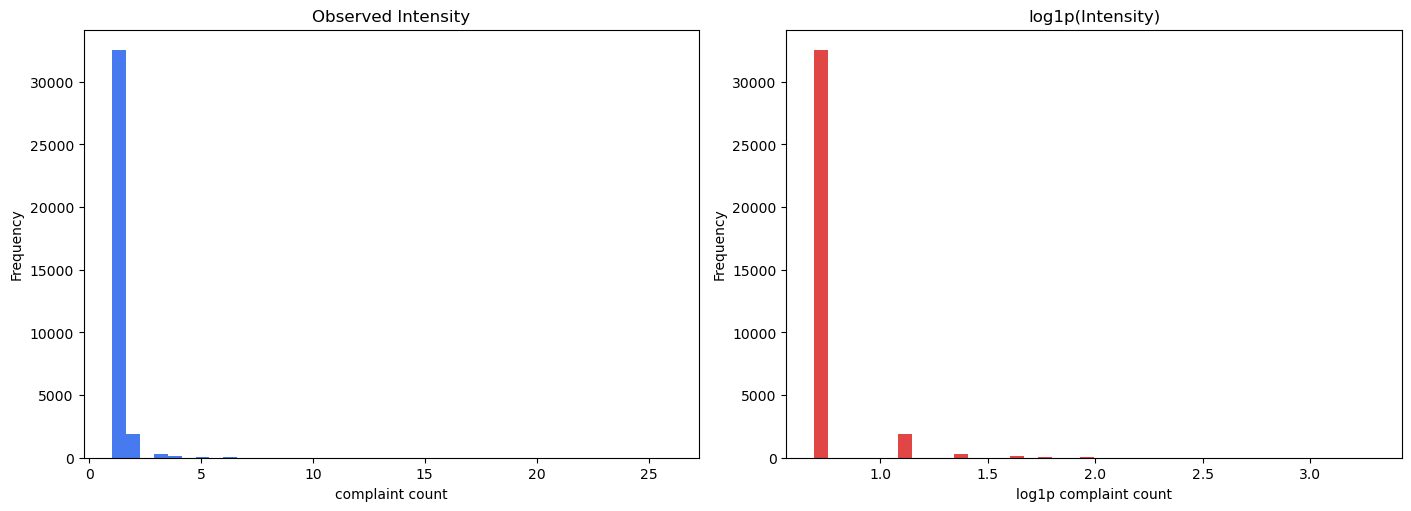

In [3]:
from project_name.modeling_stage import (
    INTENSITY_BIAS_DIAGNOSTICS_PATH,
    INTENSITY_FEATURE_IMPORTANCE_PATH,
    INTENSITY_LEAKAGE_AUDIT_PATH,
    INTENSITY_PREDICTIONS_PATH,
    INTENSITY_RESULTS_PATH,
    compact_modeling_summary,
    feature_catalog,
    load_modeling_frame,
    run_intensity_ml,
    summarize_feature_groups,
)

observed = load_modeling_frame(view_name="strict_main", include_geometry=False, observed_only=True)
display(summarize_feature_groups(observed))
display(feature_catalog(observed).head(40))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
pd.to_numeric(observed["intensity"], errors="coerce").plot.hist(ax=axes[0], bins=40, color="#2563EB", alpha=0.85)
axes[0].set_title("Observed Intensity")
axes[0].set_xlabel("complaint count")
np.log1p(pd.to_numeric(observed["intensity"], errors="coerce")).plot.hist(ax=axes[1], bins=40, color="#DC2626", alpha=0.85)
axes[1].set_title("log1p(Intensity)")
axes[1].set_xlabel("log1p complaint count")
plt.show()

In [ ]:
results, predictions, feature_importance = run_intensity_ml(observed)

display(compact_modeling_summary(results, ["mae", "rmse", "r2"]).head(30))
display(results.sort_values(["mae", "rmse"], ascending=[True, True], kind="stable").head(30))
display(feature_importance.head(30))

print(f"saved: {INTENSITY_RESULTS_PATH}")
print(f"saved: {INTENSITY_PREDICTIONS_PATH}")
print(f"saved: {INTENSITY_FEATURE_IMPORTANCE_PATH}")
print(f"saved: {INTENSITY_BIAS_DIAGNOSTICS_PATH}")
print("incremental checkpoints: data/processed/modeling/diagnostics/modeling_stage/checkpoints/intensity")

/home/map10194/miniconda3/envs/urban-flood-stress/lib/python3.11/site-packages/pandas/core/nanops.py:1672: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/home/map10194/miniconda3/envs/urban-flood-stress/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/map10194/miniconda3/envs/urban-flood-stress/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/map10194/miniconda3/envs/urban-flood-stress/lib/python3.11/site-packages/pandas/core/nanops.py:1672: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/home/map10194/miniconda3/envs/urban-flood-stress/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encounte

In [ ]:
results = pd.read_csv(INTENSITY_RESULTS_PATH)
predictions = pd.read_parquet(INTENSITY_PREDICTIONS_PATH)
feature_importance = pd.read_csv(INTENSITY_FEATURE_IMPORTANCE_PATH)
bias = pd.read_csv(INTENSITY_BIAS_DIAGNOSTICS_PATH)
leakage_audit = pd.read_csv(INTENSITY_LEAKAGE_AUDIT_PATH)

metric_cols = [
    "rmse",
    "mae",
    "r2",
    "spearman_correlation",
    "pearson_correlation",
    "median_absolute_error",
    "train_mae",
    "validation_mae",
    "test_mae",
    "cv_validation_primary_score",
    "train_vs_validation_gap",
    "validation_vs_test_gap",
    "possible_overfitting",
    "possible_test_degradation",
]
display(results[["model_name", "split_strategy", "status"] + [c for c in metric_cols if c in results.columns]].query("status == 'ok'"))
display(bias.head(50))
display(leakage_audit[leakage_audit["excluded_from_predictors"]].head(30))

## Archetype and Anomaly Error Diagnostics

Cluster labels are used here for residual diagnostics, not as a default predictor.
This helps identify whether heavy-event, compound, or unusual event regimes are systematically underpredicted.

In [ ]:
CLUSTER_PATH = ROOT / "data" / "processed" / "modeling" / "clustering_event_archetypes.parquet"
ANOMALY_PATH = ROOT / "data" / "processed" / "modeling" / "anomaly_event_scores.parquet"

if CLUSTER_PATH.exists() and ANOMALY_PATH.exists():
    clusters = pd.read_parquet(CLUSTER_PATH)[
        ["event_id", "combined_cluster_id", "cluster_label"]
    ].copy()
    anomalies = pd.read_parquet(ANOMALY_PATH)[
        ["event_id", "anomaly_score", "anomaly_flag", "anomaly_method_agreement"]
    ].copy()
    intensity_cluster_diag = (
        predictions.merge(clusters, on="event_id", how="left")
        .merge(anomalies, on="event_id", how="left")
    )
    intensity_cluster_diag = intensity_cluster_diag[intensity_cluster_diag["set_name"].eq("test")].copy()
    intensity_cluster_diag["residual"] = intensity_cluster_diag["y_true"] - intensity_cluster_diag["y_pred"]
    intensity_cluster_diag["absolute_error"] = intensity_cluster_diag["residual"].abs()
    intensity_by_cluster = (
        intensity_cluster_diag.groupby(["combined_cluster_id", "cluster_label"], dropna=False)
        .agg(
            n_events=("event_id", "size"),
            mae=("absolute_error", "mean"),
            mean_residual=("residual", "mean"),
            underprediction_rate=("residual", lambda s: pd.Series(s).gt(0).mean()),
            mean_anomaly_score=("anomaly_score", "mean"),
            anomaly_share=("anomaly_flag", lambda s: pd.Series(s).fillna(False).astype(bool).mean()),
        )
        .reset_index()
        .sort_values("mae", ascending=False, kind="stable")
    )
    intensity_by_cluster.to_csv(
        ROOT / "data" / "processed" / "modeling" / "diagnostics_intensity_by_cluster.csv",
        index=False,
    )
    display(intensity_by_cluster)
else:
    print("Cluster/anomaly outputs are not available yet. Run 13_clustering-anomaly first.")

In [ ]:
best_row = (
    results.query("status == 'ok'")
    .sort_values(["mae", "rmse"], ascending=[True, True], kind="stable")
    .iloc[0]
)
best_predictions = predictions[
    (predictions["model_name"] == best_row["model_name"])
    & (predictions["split_strategy"] == best_row["split_strategy"])
    & (predictions["set_name"] == "test")
].copy()
best_predictions["residual"] = best_predictions["y_true"] - best_predictions["y_pred"]

fig, axes = plt.subplots(2, 2, figsize=(16, 11), constrained_layout=True)
axes[0, 0].scatter(best_predictions["y_true"], best_predictions["y_pred"], alpha=0.5, color="#2563EB")
axes[0, 0].plot(
    [best_predictions["y_true"].min(), best_predictions["y_true"].max()],
    [best_predictions["y_true"].min(), best_predictions["y_true"].max()],
    linestyle="--",
    color="#64748B",
)
axes[0, 0].set_title("Observed vs Predicted Intensity")
axes[0, 0].set_xlabel("observed")
axes[0, 0].set_ylabel("predicted")

axes[0, 1].hist(pd.to_numeric(best_predictions["residual"], errors="coerce").dropna(), bins=40, color="#DC2626", alpha=0.85)
axes[0, 1].set_title("Residual Distribution")
axes[0, 1].set_xlabel("observed - predicted")

top_features = feature_importance.head(20).sort_values("importance", kind="stable")
axes[1, 0].barh(top_features["feature"], top_features["importance"], color="#059669")
axes[1, 0].set_title("Top Feature Importances")
axes[1, 0].set_xlabel("importance")

bias.query("bias_dimension == 'borough'").plot.barh(x="group_value", y="mae", ax=axes[1, 1], color="#7C3AED", legend=False)
axes[1, 1].set_title("MAE by Borough")
axes[1, 1].set_xlabel("MAE")
plt.show()